# S6E9: FT-Transformer (Feature Tokenizer Transformer)
Treating Tabular Data exactly like an LLM treats text. This pushes both numerical and categorical features into a massive Self-Attention space.
If you find this powerful, please upvote!

In [1]:
try:
    from colorama import Fore, Style
except:
    %pip install -q colorama
    from colorama import Fore, Style

import os, sys
import pandas as pd
import numpy as np, random

import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import QuantileTransformer, OrdinalEncoder, LabelEncoder, KBinsDiscretizer, TargetEncoder

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 500)

print("Libraries loaded successfully.")

# def seed_everything(seed: int):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)

def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU setups
    
    # Enforce PyTorch deterministic operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Enable strict determinism in modern PyTorch versions
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(42)

Libraries loaded successfully.


In [2]:
# 1. Load Data
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/test.csv')
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')
orig = pd.read_csv('/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv')

orig = orig.drop(columns=['Buyer_ID'], errors='ignore')
orig = orig.dropna()
orig['id'] = -1

TARGET = 'Will_Buy_EV'
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})
train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})

y = train[TARGET]

cat_cols = train.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = [c for c in train.columns if c not in cat_cols + ['id', TARGET]]

# train = pd.concat([train, orig], axis=0).reset_index(drop=True)
# print(f"Combined Train size: {train.shape}")
print(f"Loaded dataset train size: {train.shape}")

Loaded dataset train size: (668665, 15)


In [3]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]

combined = pd.concat([train, test], ignore_index=True)

digits_cols = []
cols_select = ["Annual_Income_USD", "Daily_Commute_km", "Age"] #

for col in cols_select:
    scaled = np.rint(combined[col] * 10**4).astype("int64")
    for k in range(-4, 4):
        dig_col = f"{col}_digit{k}"
        combined[dig_col] = (scaled // 10**(k + 4) % 10).astype('int8')
        digits_cols.append(dig_col)

train = combined.iloc[:len(train)][FEATURES+[TARGET]+digits_cols]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES+digits_cols]
# orig  = combined.iloc[len(train)+len(test):]

# Check nunique, and find which ones are < 2
unique_counts = train[digits_cols].nunique()
drop_cols = unique_counts[unique_counts < 2].index.tolist()

train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

# update digit cols for keep
digits_cols = [item for item in set(digits_cols) if item not in set(drop_cols)]
print(f"Total digit features: {len(digits_cols)}\n")
cat_cols.extend(digits_cols)

del combined

train

Total digit features: 9



,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Age_digit0,Age_digit1
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0.0,7,8,8,2,4,3,2,6,6
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0.0,0,0,0,0,0,5,0,8,3
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1.0,9,8,3,4,8,6,3,6,2
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0.0,0,8,5,3,7,3,2,6,6
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0.0,8,9,8,7,8,0,5,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,0.0,0,9,0,1,4,7,2,0,3
668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,0.0,0,9,9,9,0,5,0,2,3
668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,0.0,1,9,7,1,2,4,2,4,6
668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,0.0,3,2,9,5,7,3,4,1,5


In [4]:
## -- 2. Feature Engineering
def feature_engineering(df1):
    df = df1.copy()
    # df['Subsidy_Available_Num'] = (df['Subsidy_Available'] == 'Yes').astype(int)
    # df['Home_Charging_Num'] = (df['Home_Charging_Possible'] == 'Yes').astype(int)

    anxiety_map = {'Low': 0, 'Medium': 1, 'High': 2}
    if 'Range_Anxiety_Level' in df.columns:
        df['Anxiety_Score'] = df['Range_Anxiety_Level'].map(anxiety_map)
        
    # df['Sub_x_Env'] = df['Subsidy_Available_Num'] * df['Environmental_Concern_Level']
    # df['Sub_x_Home'] = df['Subsidy_Available_Num'] * df['Home_Charging_Num']
    df['Income_Per_Age'] = df['Annual_Income_USD'] / (df['Age'])

    # df.drop(columns=['Subsidy_Available_Num', 'Home_Charging_Num'], inplace=True)
    return df
    
num_cols.extend([ 'Anxiety_Score', 'Income_Per_Age',]) # 'Sub_x_Env', 'Sub_x_Home', 

X = feature_engineering(train)
X_test = feature_engineering(test)
te_cols = [] # 'Env_inc100_combo'
# ---------------------------------------
# X = train.copy()
# X_test = test.copy()

X = X[cat_cols+num_cols]
X_test = X_test[cat_cols+num_cols]

for c in num_cols:
    X[c] = X[c].fillna(X[c].median())
    X_test[c] = X_test[c].fillna(X[c].median())

X

,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Annual_Income_USD_digit1,Daily_Commute_km_digit0,Age_digit1,Annual_Income_USD_digit0,Annual_Income_USD_digit3,Annual_Income_USD_digit2,Age_digit0,Daily_Commute_km_digit1,Daily_Commute_km_digit-1,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Anxiety_Score,Income_Per_Age
0,Male,Suburban,Sedan,Yes,No,Low,8,3,6,7,2,8,6,2,4,66,92887.0,23.4,2,3,7,1.0,0,1407.378788
1,Male,Rural,SUV,Yes,No,Low,0,5,3,0,0,0,8,0,0,38,30000.0,5.0,1,2,2,4.0,0,789.473684
2,Female,Urban,Sedan,No,Yes,Low,8,6,2,9,4,3,6,3,8,26,94389.0,36.8,1,8,15,5.0,0,3630.346154
3,Male,Suburban,Hatchback,Yes,No,Low,8,3,6,0,3,5,6,2,7,66,73580.0,23.7,2,6,9,3.0,0,1114.848485
4,Male,Suburban,Hatchback,Yes,No,Low,9,0,5,8,7,8,4,5,8,54,57898.0,50.8,1,2,3,3.0,0,1072.185185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,Male,Urban,Sedan,No,Yes,Medium,9,7,3,0,1,0,0,2,4,30,71090.0,27.4,2,5,6,5.0,1,2369.666667
668661,Female,Suburban,SUV,Yes,Yes,Low,9,5,3,0,9,9,2,0,0,32,129990.0,5.0,2,5,4,1.0,0,4062.187500
668662,Female,Suburban,Hatchback,Yes,Yes,Low,9,4,6,1,1,7,4,2,2,64,121791.0,24.2,1,5,6,1.0,0,1902.984375
668663,Female,Rural,SUV,Yes,Yes,Low,2,3,5,3,5,9,1,4,7,51,115923.0,43.7,2,0,0,1.0,0,2273.000000


In [5]:
full_data = pd.concat([X, X_test])
# full_data['Anxiety_Score'] = full_data['Range_Anxiety_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

cat_dims  = []
for c in cat_cols:
    le = LabelEncoder().fit(full_data[c].astype(str))
    X[c] = le.transform(X[c].astype(str))
    X_test[c] = le.transform(X_test[c].astype(str))
    cat_dims.append(len(le.classes_))

# X_cat = X[cat_cols]
# X_num = X[num_cols]

# X_test_cat = X_test[cat_cols]
# X_test_num = X_test[num_cols]

del full_data

for k, v in zip(cat_cols, cat_dims):
    print(f"{k:>25s}: {v}")

                   Gender: 3
                City_Type: 3
         Current_Car_Type: 4
   Home_Charging_Possible: 2
        Subsidy_Available: 2
      Range_Anxiety_Level: 3
 Annual_Income_USD_digit1: 10
  Daily_Commute_km_digit0: 10
               Age_digit1: 5
 Annual_Income_USD_digit0: 10
 Annual_Income_USD_digit3: 10
 Annual_Income_USD_digit2: 10
               Age_digit0: 10
  Daily_Commute_km_digit1: 10
 Daily_Commute_km_digit-1: 10


In [6]:
# 4. PyTorch Dataset & FT-Transformer Architecture
class TabularDataset(Dataset):
    def __init__(self, x_cat, x_num, y=None):
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.x_num = torch.tensor(x_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
        
    def __len__(self):
        return len(self.x_num)
        
    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_cat[idx], self.x_num[idx], self.y[idx]
        return self.x_cat[idx], self.x_num[idx]

class FTTransformer(nn.Module):
    def __init__(self, cat_dims, num_features, d_token=32, n_blocks=3, n_heads=4, ff_dropout=0.1):
        super().__init__()
        self.cat_dims = cat_dims
        self.num_features = num_features
        
        # Tokenize Categoricals
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(num_classes, d_token) for num_classes in cat_dims
        ])
        
        # Tokenize Numericals (each numerical feature gets multiplied by a learned weight vector to become d_token dim)
        self.num_embeddings = nn.Parameter(torch.randn(num_features, d_token))
        self.num_biases = nn.Parameter(torch.randn(num_features, d_token))
        
        # [CLS] Token (like in BERT, used for final classification)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        
        # Standard Transformer Encoder Blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, 
            nhead=n_heads, 
            dim_feedforward=d_token * 2, 
            dropout=ff_dropout, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)
        
        # Final prediction head
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, d_token // 2),
            nn.ReLU(),
            nn.Linear(d_token // 2, 1)
        )

    def forward(self, x_cat, x_num):
        batch_size = x_num.size(0)
        
        # 1. Process Categoricals
        cat_embs = []
        for i, emb in enumerate(self.cat_embeddings):
            cat_embs.append(emb(x_cat[:, i]).unsqueeze(1)) # Shape: (batch_size, 1, d_token)
            
        # 2. Process Numericals
        # x_num is (batch_size, num_features)
        # self.num_embeddings is (num_features, d_token)
        num_embs = x_num.unsqueeze(-1) * self.num_embeddings.unsqueeze(0) + self.num_biases.unsqueeze(0)
        
        # 3. Combine
        if len(cat_embs) > 0:
            cat_embs = torch.cat(cat_embs, dim=1)
            x = torch.cat([cat_embs, num_embs], dim=1) # Shape: (batch_size, num_cat + num_num, d_token)
        else:
            x = num_embs
            
        # 4. Add CLS Token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1) # Shape: (batch_size, 1 + num_cat + num_num, d_token)
        
        # 5. Transformer Pass
        x = self.transformer(x)
        
        # 6. Extract CLS token output and classify
        cls_out = x[:, 0, :]
        return self.head(cls_out).squeeze(1)


In [7]:
USE_FULL_TRAIN = True

x_sample, x_sample2 = train_test_split(pd.concat([X, y], axis=1), train_size=300_000, stratify=y, random_state=0)
train_X = pd.concat([X, y], axis=1).copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

print(train_X.shape)
train_X

(668665, 25)


,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Annual_Income_USD_digit1,Daily_Commute_km_digit0,Age_digit1,Annual_Income_USD_digit0,Annual_Income_USD_digit3,Annual_Income_USD_digit2,Age_digit0,Daily_Commute_km_digit1,Daily_Commute_km_digit-1,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Anxiety_Score,Income_Per_Age,Will_Buy_EV
0,1,1,2,1,0,1,8,3,4,7,2,8,6,2,4,66,92887.0,23.4,2,3,7,1.0,0,1407.378788,0
1,1,0,1,1,0,1,0,5,1,0,0,0,8,0,0,38,30000.0,5.0,1,2,2,4.0,0,789.473684,0
2,0,2,2,0,1,1,8,6,0,9,4,3,6,3,8,26,94389.0,36.8,1,8,15,5.0,0,3630.346154,1
3,1,1,0,1,0,1,8,3,4,0,3,5,6,2,7,66,73580.0,23.7,2,6,9,3.0,0,1114.848485,0
4,1,1,0,1,0,1,9,0,3,8,7,8,4,5,8,54,57898.0,50.8,1,2,3,3.0,0,1072.185185,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,1,2,2,0,1,2,9,7,1,0,1,0,0,2,4,30,71090.0,27.4,2,5,6,5.0,1,2369.666667,0
668661,0,1,1,1,1,1,9,5,1,0,9,9,2,0,0,32,129990.0,5.0,2,5,4,1.0,0,4062.187500,0
668662,0,1,0,1,1,1,9,4,4,1,1,7,4,2,2,64,121791.0,24.2,1,5,6,1.0,0,1902.984375,0
668663,0,0,1,1,1,1,2,3,3,3,5,9,1,4,7,51,115923.0,43.7,2,0,0,1.0,0,2273.000000,0


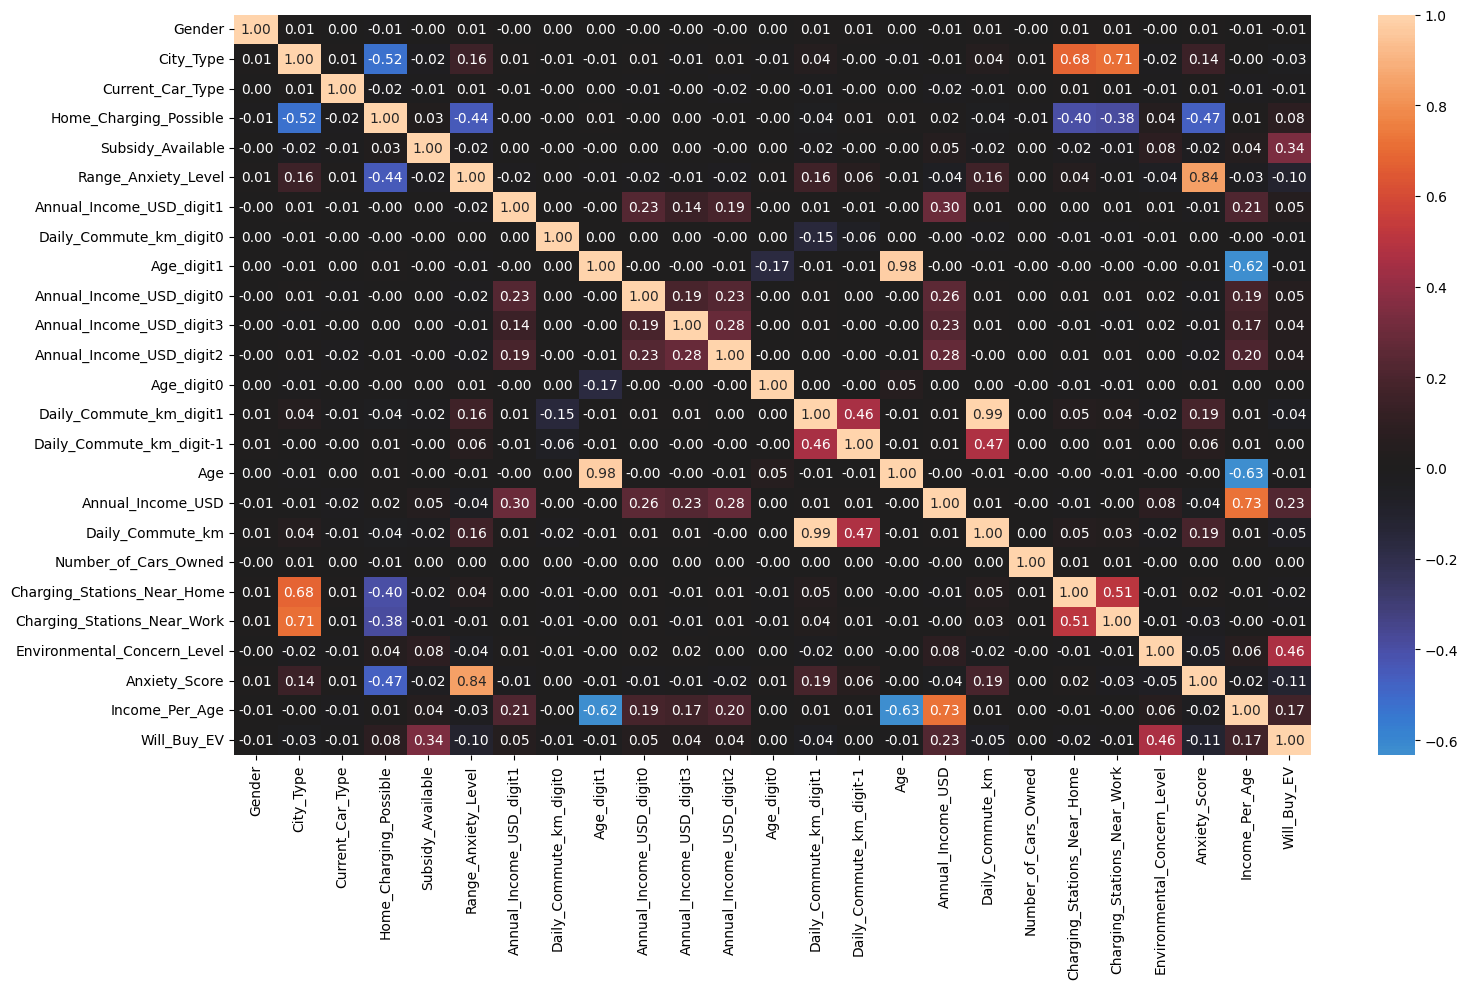

In [8]:
plt.figure(figsize=(16, 10))
sns.heatmap(train_X.corr(), center=0, annot=True, fmt='.2f')
plt.tight_layout()
plt.show()

In [9]:
np.floor(train_X['Annual_Income_USD'] / 100)[0], (train_X['Annual_Income_USD'] // 100)[0]

(np.float64(928.0), np.float64(928.0))

In [10]:
%%time

# Training Loop (GPU Accelerated)

USE_TE = False
MODEL_NAME = f"torch_FTT({train_X.shape[1]})se"

BATCH_SIZE = 1024
EPOCHS = 20
FOLDS  = 10

X_1 = train_X.drop([TARGET], axis=1)
y_1 = train_X[TARGET]

print(f"\n🚀 Training {MODEL_NAME} with {FOLDS } folds", end=" | ")
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X_1))
test_preds = np.zeros(len(X_test))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on Device: {device}")

learning_rate = 1e-3
d_token  = 64 # 32
n_heads  = 8  # 4
n_blocks = 3  # 3
ff_dropout = 0.1
weight_decay = 1e-4 # 0.0

best_epochs = []
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_1, y_1), 1):
    print(f"\n--- FOLD {fold}/{FOLDS} ---")    
    X_train, X_valid = X_1.iloc[train_idx].copy(), X_1.iloc[val_idx].copy()
    y_train, y_valid = y_1.iloc[train_idx].values, y_1.iloc[val_idx].values
    X_test_fold = X_test.copy()

    # Target encoding
    if USE_TE:
        te_cols = te_cols
        print(f"Target encoding ({len(te_cols)}) features", end=" | ")
        TE = TargetEncoder(cv=5, smooth='auto', shuffle=True, random_state=42)
        tr_enc = TE.fit_transform(X_train[te_cols], y_train)
        val_enc = TE.transform(X_valid[te_cols])
        tst_enc = TE.transform(X_test_fold[te_cols])

        te_names = [f"_{col}TE" for col in te_cols]
        X_train[te_names] = tr_enc
        X_valid[te_names] = val_enc
        X_test_fold[te_names] = tst_enc

    # all_feats = cat_cols+num_cols+te_names if USE_TE else cat_cols+num_cols

    # cat_dims  = []
    # full_data = pd.concat([
    #     X_train[all_feats],
    #     X_valid[all_feats],
    #     X_test_fold[all_feats],
    # ])
    # for c in cat_cols:
    #     le = LabelEncoder().fit(full_data[c].astype(str))
    #     X_train[c] = le.transform(X_train[c].astype(str))
    #     X_valid[c] = le.transform(X_valid[c].astype(str))
    #     X_test_fold[c] = le.transform(X_test_fold[c].astype(str))
    #     cat_dims.append(len(le.classes_))

    print(f"train={X_train.shape}, valid={X_valid.shape}")
    X_train_cat, X_train_num = X_train[cat_cols], X_train[num_cols+te_names] if USE_TE else X_train[num_cols]
    X_valid_cat, X_valid_num = X_valid[cat_cols], X_valid[num_cols+te_names] if USE_TE else X_valid[num_cols]
    X_test_cat, X_test_num = X_test_fold[cat_cols], X_test_fold[num_cols+te_names] if USE_TE else X_test_fold[num_cols]

    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    X_train_num = qt.fit_transform(X_train_num)
    X_valid_num = qt.transform(X_valid_num)
    X_test_num  = qt.transform(X_test_num)

    train_dataset = TabularDataset(np.asarray(X_train_cat), np.asarray(X_train_num), y_train)
    val_dataset   = TabularDataset(np.asarray(X_valid_cat), np.asarray(X_valid_num), y_valid)
    test_dataset  = TabularDataset(np.asarray(X_test_cat), np.asarray(X_test_num))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = FTTransformer(
        cat_dims=cat_dims,
        num_features=X_train_num.shape[1],
        d_token=d_token,
        n_blocks=n_blocks,
        n_heads=n_heads,
        ff_dropout=ff_dropout,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    # ----------------------------------------------------------------------------
    warmup_epochs = 2
    scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
    scheduler2 = CosineAnnealingLR(optimizer, T_max=EPOCHS - warmup_epochs)
    scheduler  = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[warmup_epochs])
    # ----------------------------------------------------------------------------

    best_val_auc = 0
    best_epoch   = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for b_cat, b_num, b_y in train_loader:
            b_cat, b_num, b_y = b_cat.to(device), b_num.to(device), b_y.to(device)

            optimizer.zero_grad()
            logits = model(b_cat, b_num)
            loss = criterion(logits, b_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        model.eval()
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for b_cat, b_num, b_y in val_loader:
                b_cat, b_num = b_cat.to(device), b_num.to(device)
                logits = model(b_cat, b_num)
                val_preds.extend(torch.sigmoid(logits).cpu().numpy())
                val_targets.extend(b_y.cpu().numpy())

        val_auc = roc_auc_score(val_targets, val_preds)
        print(f"Epoch {epoch+1}/{EPOCHS} | AUC: {val_auc:.6f}")

        if val_auc > best_val_auc:
            best_epoch = epoch+1
            best_val_auc = val_auc
            torch.save(model.state_dict(), f"ft_fold_{fold}.pth")
            oof_preds[val_idx] = val_preds
        
    fold_score = np.round(roc_auc_score(y_valid, oof_preds[val_idx]), 6)
    fold_scores.append(fold_score)
    print('-'*40)
    print(f"-> Fold {fold} CONVERGED: #{best_epoch} | AUC: {Fore.YELLOW}{Style.BRIGHT}{fold_score}{Style.RESET_ALL}\n")
    best_epochs.append(best_epoch)

    model.load_state_dict(torch.load(f"ft_fold_{fold}.pth", weights_only=True))
    model.eval()
    fold_test_preds = []
    with torch.no_grad():
        for b_cat, b_num in test_loader:
            b_cat, b_num = b_cat.to(device), b_num.to(device)
            logits = model(b_cat, b_num)
            fold_test_preds.extend(torch.sigmoid(logits).cpu().numpy())
    test_preds += np.array(fold_test_preds) / FOLDS

    torch.cuda.empty_cache()

# ---- CV summary ----  
oof_auc = np.round(roc_auc_score(y_1, oof_preds), 6)

print("\n" + "="*50)
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | epochs={EPOCHS} | {X_train.shape}")
print("="*50)
for i, (sc, ep) in enumerate(zip(fold_scores, best_epochs), 1):  
    print(f" • Fold {i} AUC: {sc} at epoch #{ep}")  

print("-------------------------------------------------|")  
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-------------------------------------------------|")  
# print(f"{(time() - t0) / 60:.2f} mins\n")

!rm /kaggle/working/*.pth


🚀 Training torch_FTT(25)se with 10 folds | Training on Device: cuda

--- FOLD 1/10 ---
train=(601798, 24), valid=(66867, 24)
Epoch 1/20 | AUC: 0.936354
Epoch 2/20 | AUC: 0.938058
Epoch 3/20 | AUC: 0.938375
Epoch 4/20 | AUC: 0.938791
Epoch 5/20 | AUC: 0.938724
Epoch 6/20 | AUC: 0.939016
Epoch 7/20 | AUC: 0.939842
Epoch 8/20 | AUC: 0.940080
Epoch 9/20 | AUC: 0.939843
Epoch 10/20 | AUC: 0.940355
Epoch 11/20 | AUC: 0.940433
Epoch 12/20 | AUC: 0.940593
Epoch 13/20 | AUC: 0.940898
Epoch 14/20 | AUC: 0.941035
Epoch 15/20 | AUC: 0.940936
Epoch 16/20 | AUC: 0.941160
Epoch 17/20 | AUC: 0.941140
Epoch 18/20 | AUC: 0.941204
Epoch 19/20 | AUC: 0.941251
Epoch 20/20 | AUC: 0.941257
----------------------------------------
-> Fold 1 CONVERGED: #20 | AUC: 0.941257


--- FOLD 2/10 ---
train=(601798, 24), valid=(66867, 24)
Epoch 1/20 | AUC: 0.935976
Epoch 2/20 | AUC: 0.937995
Epoch 3/20 | AUC: 0.938208
Epoch 4/20 | AUC: 0.938435
Epoch 5/20 | AUC: 0.939046
Epoch 6/20 | AUC: 0.938737
Epoch 7/20 | AUC: 0.9

In [11]:
# ==================================================
# 3-FOLD CV: torch_FTT30_se | epochs=20 | (200000, 24)
# ==================================================
#  • Fold 1 AUC: 0.940098 at epoch #19
#  • Fold 2 AUC: 0.939767 at epoch #18
#  • Fold 3 AUC: 0.938375 at epoch #16
# -------------------------------------------------|
# OOF AUC: 0.939364
# AVG AUC: 0.939413 ± 0.000747
# -------------------------------------------------|
# Wall time: 8min 38s

print("\n" + "="*50)
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | epochs={EPOCHS} | {X_train.shape}")
print("="*50)
for i, (sc, ep) in enumerate(zip(fold_scores, best_epochs), 1):  
    print(f" • Fold {i} AUC: {sc} at epoch #{ep}")  

print("-------------------------------------------------|") 
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-------------------------------------------------|") 


10-FOLD CV: torch_FTT(25)se | epochs=20 | (601799, 24)
 • Fold 1 AUC: 0.941257 at epoch #20
 • Fold 2 AUC: 0.941196 at epoch #20
 • Fold 3 AUC: 0.941896 at epoch #18
 • Fold 4 AUC: 0.942364 at epoch #20
 • Fold 5 AUC: 0.942934 at epoch #18
 • Fold 6 AUC: 0.943484 at epoch #20
 • Fold 7 AUC: 0.941858 at epoch #18
 • Fold 8 AUC: 0.943094 at epoch #20
 • Fold 9 AUC: 0.943622 at epoch #19
 • Fold 10 AUC: 0.941287 at epoch #18
-------------------------------------------------|
OOF AUC: 0.942279
AVG AUC: 0.942299 ± 0.000888
-------------------------------------------------|


In [12]:
# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{MODEL_NAME}_{oof_auc}.npy", oof_preds)
print(f"💾 Saved 'oof_{MODEL_NAME}_{oof_auc}.npy'")

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{MODEL_NAME}_{oof_auc}.npy", test_preds)
print(f"💾 Saved 'test_{MODEL_NAME}_{oof_auc}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission[TARGET] = test_preds
submission.to_csv(f"submission_{MODEL_NAME}_{oof_auc}.csv", index=False)
print(f"💾 Saved 'submission_{MODEL_NAME}_{oof_auc}.csv'")

print()
submission

💾 Saved 'oof_torch_FTT(25)se_0.942279.npy'
💾 Saved 'test_torch_FTT(25)se_0.942279.npy'
💾 Saved 'submission_torch_FTT(25)se_0.942279.csv'



,id,Will_Buy_EV
0,668665,0.011100
1,668666,0.013805
2,668667,0.004617
3,668668,0.003474
4,668669,0.020081
...,...,...
286566,955231,0.000128
286567,955232,0.277979
286568,955233,0.000853
286569,955234,0.000155


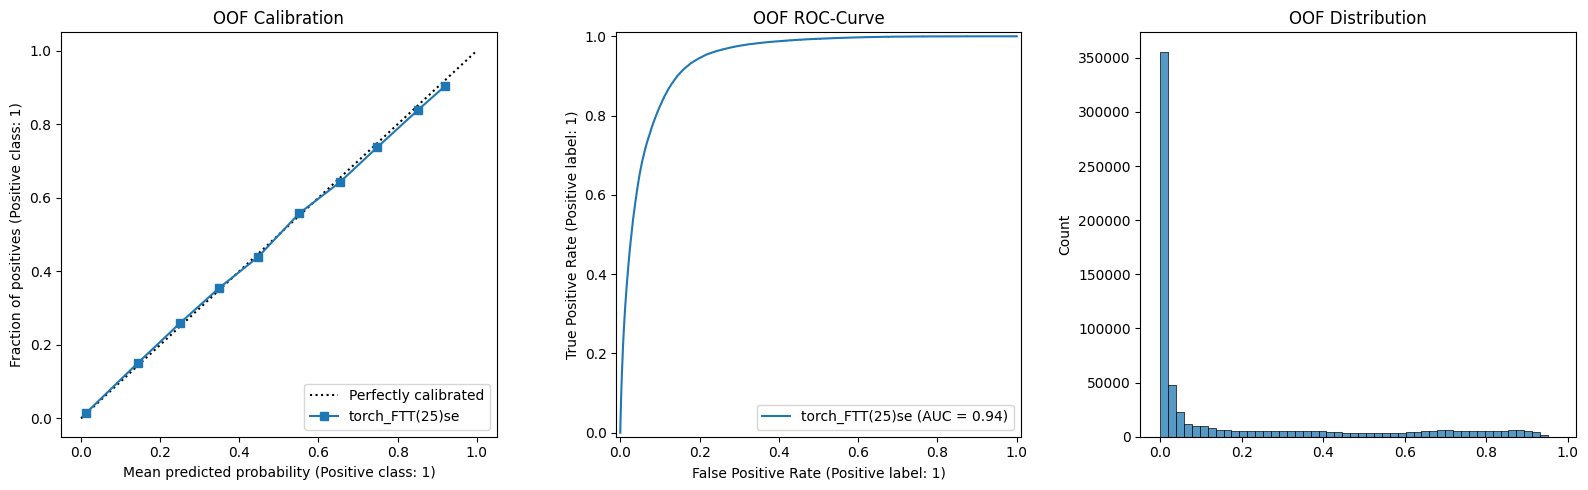

In [13]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5))

CalibrationDisplay.from_predictions(y_1, oof_preds, n_bins=10, name=MODEL_NAME, ax=axs[0])
axs[0].set_title(f"OOF Calibration")

RocCurveDisplay.from_predictions(y_1, oof_preds, name=MODEL_NAME, ax=axs[1])
axs[1].set_title(f"OOF ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"OOF Distribution")

plt.tight_layout()
plt.show()

In [14]:
# !rm -r /kaggle/working/